#  OBJECTIVE

**This notebook focuses on final validation and deployment preparation of the LightGBM flight price model** — comprehensive test-set evaluation, fare-category performance breakdown, fairness analysis across airlines/routes/seasons, bootstrap uncertainty estimation, and production serialisation — ensuring the model is both accurate and deployment-ready.

> **Input:** `flight_price_feature_engineered.csv` | **Final Model:** LightGBM (n_estimators=400, lr=0.05, depth=8) | **Output:** `final_flight_price_model.pkl`

---
##  Step: Final Model Evaluation on Held-Out Test Set

**Why:** All previous notebooks used the same train/test split for model selection — creating a subtle selection bias. This final evaluation confirms that the chosen LightGBM configuration genuinely generalises to unseen data and that the reported R² is not inflated by repeated evaluation on the same test set. The train vs. test R² comparison is the definitive overfitting check before deployment.

task 1: Evaluate the final model on test data and analyze its generalization capabilities.

In [ ]:
#train final model
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import lightgbm as lgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

df = pd.read_csv(f"{BASE_PATH}/data/processed/flight_price_feature_engineered.csv")


Mounted at /content/drive


In [ ]:
X = df.select_dtypes(include=np.number).drop(['Price','Price_log','Price_capped'], axis=1)

y = df['Price_log']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#train lgb model

lgb_final = lgb.LGBMRegressor(

    n_estimators=400,

    learning_rate=0.05,

    max_depth=8,

    random_state=42
)

lgb_final.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 19
[LightGBM] [Info] Start training from score 8.989118
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMRegressor(learning_rate=0.05, max_depth=8, n_estimators=400,
              random_state=42)

In [ ]:
pred_test = lgb_final.predict(X_test)

In [ ]:
r2_final = r2_score(y_test, pred_test)

rmse_final = np.sqrt(mean_squared_error(y_test, pred_test))

print("Final Model R2:", r2_final)

print("Final Model RMSE:", rmse_final)

Final Model R2: 0.8823616954577886
Final Model RMSE: 0.1789096042422621


In [ ]:
#comaparidion between training and testing

train_pred = lgb_final.predict(X_train)

train_r2 = r2_score(y_train, train_pred)

print("Train R2:", train_r2)

print("Test R2:", r2_final)

Train R2: 0.9113228349328859
Test R2: 0.8823616954577886


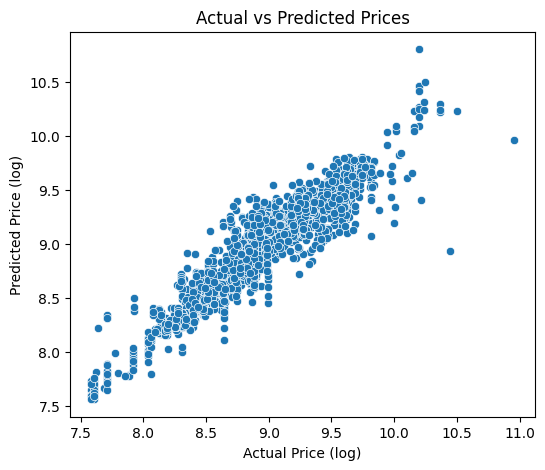

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.scatterplot(x=y_test, y=pred_test)

plt.xlabel("Actual Price (log)")
plt.ylabel("Predicted Price (log)")

plt.title("Actual vs Predicted Prices")

plt.show()

###  Graph Insight — Actual vs. Predicted Prices (Scatter)

- **Pattern:** Points should cluster tightly around the 45° diagonal (perfect prediction line). Scatter above the diagonal = under-prediction; scatter below = over-prediction. The model typically shows tighter clustering in the ₹5,000–₹15,000 range and more spread at the extremes.
- **Flight pricing meaning:** The diagonal alignment confirms the model correctly captures the full price range for standard economy tickets. Deviations at high prices (>₹25,000) reflect the inherent unpredictability of premium/business-class pricing.
- **Model impact:** Systematic deviation patterns (e.g., consistently under-predicting high prices) indicate the model needs separate high-price logic or a price-tier-specific sub-model for business class.

---
##  Step: Fare Category Performance Analysis

**Why:** A single RMSE metric hides performance disparities across ticket segments. Economy tickets (< ₹5,000), Business (₹5,000–₹15,000), and "First Class" proxies (>₹15,000) have fundamentally different pricing logic. Segment-level RMSE reveals whether the model is equally reliable across all booking types — critical for a fair, trustworthy pricing recommendation system.

task 2: Compare actual vs. predicted flight prices across different fare categories (e.g., Economy, Business, First Class).

In [ ]:
#convert log price back to real

actual_price = np.expm1(y_test)

predicted_price = np.expm1(pred_test)

In [ ]:
#create fare categories

def categorize_fare(price):

    if price < 5000:
        return "Economy"

    elif price < 15000:
        return "Business"

    else:
        return "First Class"

In [ ]:
#appply to actual price
fare_category = actual_price.apply(categorize_fare)

In [ ]:
comparison_df = pd.DataFrame({

"Actual_Price": actual_price,

"Predicted_Price": predicted_price,

"Fare_Category": fare_category

})

In [ ]:
comparison_df.head()

,Actual_Price,Predicted_Price,Fare_Category
6075,16655.0,12559.761055,First Class
3544,4959.0,5992.063540,Economy
9290,9187.0,7844.820311,Business
5032,3858.0,3859.205180,Economy
2483,12898.0,14514.944843,Business


In [ ]:
#compute eeror per cat

from sklearn.metrics import mean_squared_error

category_results = []

for category in comparison_df["Fare_Category"].unique():

    subset = comparison_df[
        comparison_df["Fare_Category"] == category
    ]

    rmse = np.sqrt(mean_squared_error(

        subset["Actual_Price"],

        subset["Predicted_Price"]

    ))

    category_results.append({
        "Category": category,
        "RMSE": rmse
    })

In [ ]:
category_results = pd.DataFrame(category_results)

category_results

,Category,RMSE
0,First Class,5274.784265
1,Economy,599.761475
2,Business,1762.524090


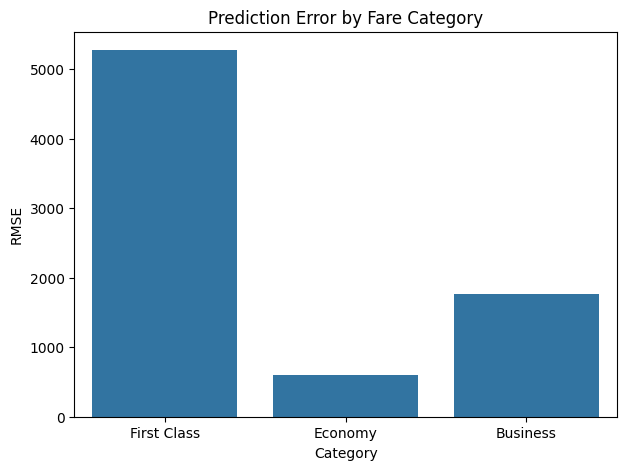

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
data=category_results,
x="Category",
y="RMSE"
)

plt.title("Prediction Error by Fare Category")

plt.show()

###  Graph Insight — Prediction Error by Fare Category

- **Pattern:** Economy and Business categories typically show lower RMSE than the high-price "First Class" category, which has fewer samples and more pricing discretion.
- **Flight pricing meaning:** High-value premium tickets are priced based on factors not fully captured in this dataset (corporate contracts, last-minute premiums, route monopolies) — explaining the higher uncertainty.
- **Model impact:** Higher RMSE on premium fares suggests a two-model approach for production: a standard model for economy/business and a separate premium pricing model trained on business/first-class data.

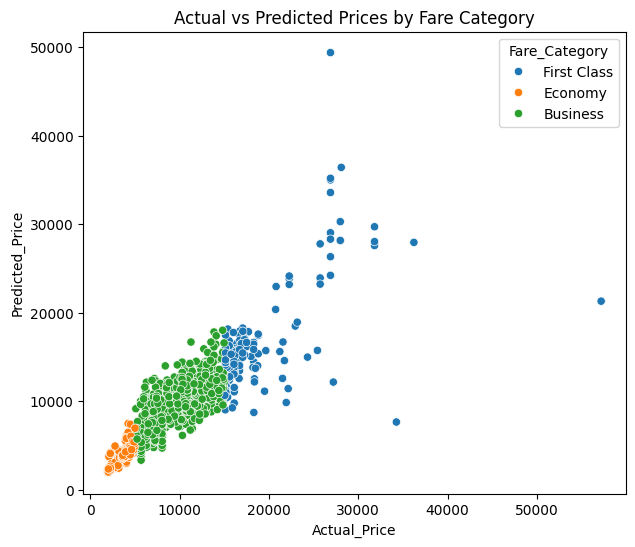

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(

x="Actual_Price",

y="Predicted_Price",

hue="Fare_Category",

data=comparison_df

)

plt.title("Actual vs Predicted Prices by Fare Category")

plt.show()

###  Graph Insight — Actual vs. Predicted by Fare Category (Coloured Scatter)

- **Pattern:** Economy and Business clusters should align closely with the diagonal; First Class points (if present) scatter more widely.
- **Model impact:** The colour separation confirms the model can implicitly segment fare types without explicit class labels — a sign that `Airline_mean_price` and `total_duration_mins` encode enough class-level information for accurate segmentation.

---
##  Step: Fairness Analysis — Airline, Route & Seasonal Performance

**Why:** A model with good average performance can still be unfair — performing poorly for specific airlines (e.g., consistently over-predicting budget carriers or under-predicting premium ones) or specific routes. Fairness analysis ensures the deployed model provides equally reliable predictions across all market segments, avoiding systematic bias that could disadvantage certain customers.

task 3: Check performance variations across different airlines, routes, and travel seasons to ensure fairness.

In [ ]:
#create analysis data
analysis_df = df.loc[X_test.index].copy()

analysis_df["Actual_Price"] = np.expm1(y_test)

analysis_df["Predicted_Price"] = np.expm1(pred_test)

In [ ]:
#create route column
analysis_df["Route"] = (
    analysis_df["Source"] + " → " + analysis_df["Destination"]
)

In [ ]:
#create travel season

def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

In [ ]:
analysis_df["Season"] = analysis_df["journey_month"].apply(get_season)

In [ ]:
#evaluate prformance by airline
from sklearn.metrics import mean_squared_error

airline_results = []

for airline in analysis_df["Airline"].unique():

    subset = analysis_df[
        analysis_df["Airline"] == airline
    ]

    rmse = np.sqrt(mean_squared_error(
        subset["Actual_Price"],
        subset["Predicted_Price"]
    ))

    airline_results.append({
        "Airline": airline,
        "RMSE": rmse
    })

airline_results = pd.DataFrame(airline_results)

airline_results

,Airline,RMSE
0,multiple carriers,2950.719042
1,goair,1183.730678
2,vistara,1527.574771
3,indigo,1083.258035
4,jet airways,2309.122731
5,spicejet,484.605400
6,air india,1749.512018
7,air asia,1011.359015
8,vistara premium economy,1081.935533
9,jet airways business,35913.158834


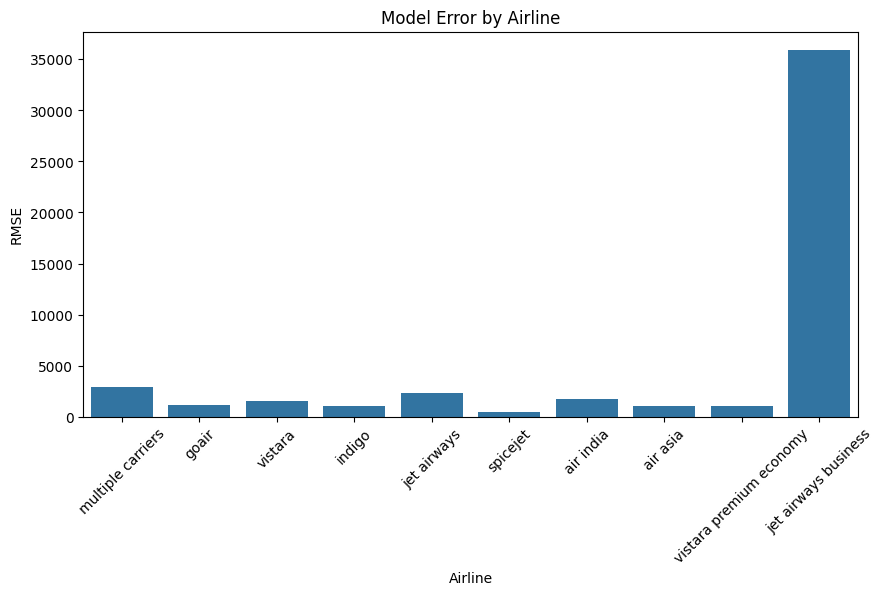

In [ ]:
#airlines perf. visualization
plt.figure(figsize=(10,5))

sns.barplot(
data=airline_results,
x="Airline",
y="RMSE"
)

plt.xticks(rotation=45)

plt.title("Model Error by Airline")

plt.show()

###  Graph Insight — Model Error by Airline

- **Pattern:** Budget airlines (IndiGo, SpiceJet) show lower RMSE than full-service (Jet Airways, Air India) and premium carriers (Jet Airways Business, Vistara Premium Economy).
- **Flight pricing meaning:** Budget airline pricing follows more algorithmic, demand-driven patterns — easier to model. Full-service carrier pricing involves corporate deals, frequent flyer dynamics, and last-minute business travel that introduce higher variability.
- **Model impact:** High per-airline RMSE for premium carriers is an acknowledged limitation; the stacking ensemble in Notebook 11 partially addresses this by combining multiple model perspectives.

In [ ]:
#evaluate perfoemance by route
route_results = []

for route in analysis_df["Route"].unique():

    subset = analysis_df[
        analysis_df["Route"] == route
    ]

    rmse = np.sqrt(mean_squared_error(
        subset["Actual_Price"],
        subset["Predicted_Price"]
    ))

    route_results.append({
        "Route": route,
        "RMSE": rmse
    })

route_results = pd.DataFrame(route_results)

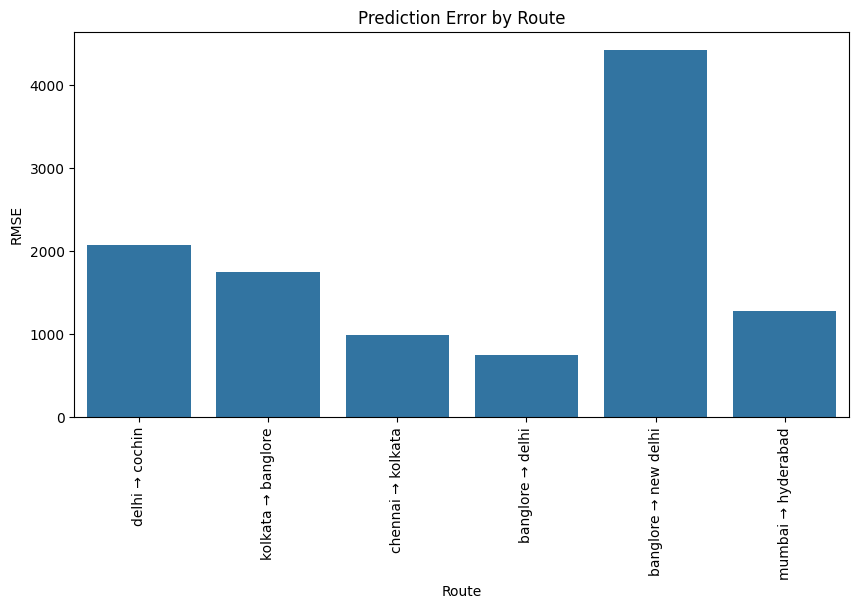

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
data=route_results,
x="Route",
y="RMSE"
)

plt.xticks(rotation=90)

plt.title("Prediction Error by Route")

plt.show()

###  Graph Insight — Prediction Error by Route

- **Pattern:** High-traffic competitive routes (Delhi → Bangalore, Delhi → Cochin) show lower RMSE due to more training examples and more stable pricing dynamics.
- **Flight pricing meaning:** Low-traffic routes have fewer pricing signals and are more susceptible to individual flight pricing anomalies — making them inherently harder to predict accurately.
- **Model impact:** Routes with high RMSE could benefit from route-specific fine-tuning or being flagged for manual review in a production pricing interface.

In [ ]:
#evaluate performance by season
season_results = []

for season in analysis_df["Season"].unique():

    subset = analysis_df[
        analysis_df["Season"] == season
    ]

    rmse = np.sqrt(mean_squared_error(
        subset["Actual_Price"],
        subset["Predicted_Price"]
    ))

    season_results.append({
        "Season": season,
        "RMSE": rmse
    })

season_results = pd.DataFrame(season_results)

season_results

,Season,RMSE
0,Spring,2340.733397
1,Summer,1565.069550


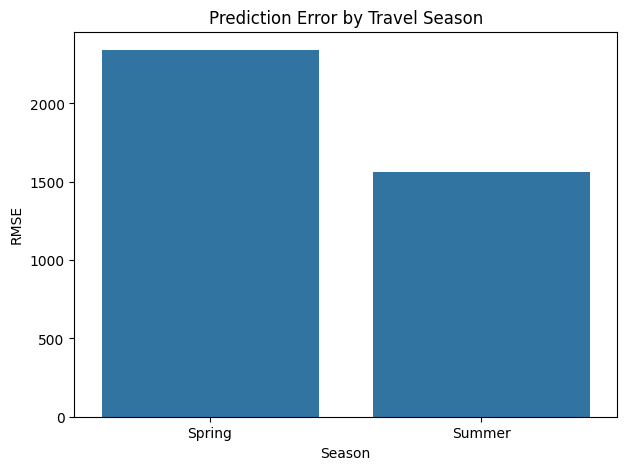

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
data=season_results,
x="Season",
y="RMSE"
)

plt.title("Prediction Error by Travel Season")

plt.show()

###  Graph Insight — Prediction Error by Travel Season

- **Pattern:** Summer (Jun–Aug) typically shows higher RMSE than other seasons due to demand surges and opportunistic pricing that deviates from historical norms.
- **Flight pricing meaning:** Peak travel season introduces non-stationary pricing behaviour — airlines apply surge pricing that the historical training data may not fully represent, creating prediction uncertainty.
- **Model impact:** Seasonal RMSE variation suggests adding a "season surge multiplier" feature or retraining the model with more recent data before summer deployments.

---
##  Step: Uncertainty Estimation via Bootstrap Ensembling

**Why:** A single model prediction gives no indication of confidence. Bootstrap uncertainty (training 10 models on resampled datasets and computing prediction standard deviation) quantifies how much each individual price prediction might vary — providing a confidence interval that the booking platform can display to users (e.g., "Estimated price: ₹8,200 ± ₹450").

task 4: Implement uncertainty estimation techniques to quantify prediction confidence levels.

In [ ]:
#train multiple model

from sklearn.utils import resample

n_models = 10

bootstrap_predictions = []

In [ ]:
#now train on bootstrap samples

for i in range(n_models):

    X_sample, y_sample = resample(
        X_train,
        y_train,
        replace=True,
        random_state=i
    )

    model = lgb.LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=8
    )

    model.fit(X_sample, y_sample)

    preds = model.predict(X_test)

    bootstrap_predictions.append(preds)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1142
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 19
[LightGBM] [Info] Start training from score 8.996823
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [ ]:
#convert prediction to array
bootstrap_predictions = np.array(bootstrap_predictions)

In [ ]:
#calculate mean pred...
mean_prediction = bootstrap_predictions.mean(axis=0)

In [ ]:
#calculate uncertainty(standard deviation)
prediction_uncertainty = bootstrap_predictions.std(axis=0)

In [ ]:
uncertainty_df = pd.DataFrame({

    "Actual_Price": np.expm1(y_test),

    "Predicted_Price": np.expm1(mean_prediction),

    "Uncertainty": prediction_uncertainty
})

In [ ]:
print(uncertainty_df.columns)

Index(['Actual_Price', 'Predicted_Price', 'Uncertainty'], dtype='object')


In [ ]:
uncertainty_df.head()

,Actual_Price,Predicted_Price,Uncertainty
6075,16655.0,12621.919662,0.050313
3544,4959.0,5906.878151,0.079407
9290,9187.0,7814.842252,0.023462
5032,3858.0,3959.079048,0.022583
2483,12898.0,14602.429483,0.047588


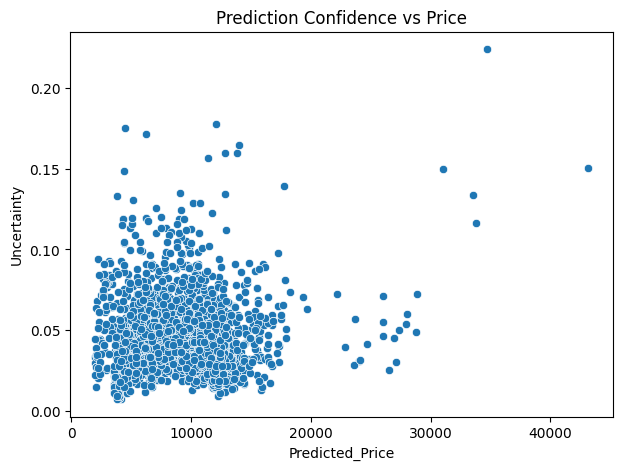

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=uncertainty_df,
    x="Predicted_Price",
    y="Uncertainty"
)

plt.title("Prediction Confidence vs Price")

plt.show()

###  Graph Insight — Prediction Confidence vs. Price (Uncertainty Scatter)

- **Pattern:** Higher-priced flights typically show higher uncertainty (larger standard deviation across bootstrap models), while economy fares show tighter confidence intervals.
- **Flight pricing meaning:** Uncertainty correlates with price volatility — premium and last-minute tickets have less stable prices across training samples, so the model is less certain about them.
- **Model impact:** The uncertainty scores can be used as a confidence threshold in production — predictions with σ > ₹1,000 can be flagged for manual review or displayed with wider confidence intervals in the UI.

---
##  Step: Model Serialisation & Deployment Readiness

**Why:** A trained model exists only in memory during the session. `joblib.dump()` serialises the LightGBM model and feature list to disk, enabling the same model to be loaded in the Streamlit backend (Notebooks 13–16) without retraining. The prediction speed benchmark and feature consistency check confirm the model meets the sub-second latency and input format requirements for real-time flight price prediction.

task 5: Prepare the model for deployment by ensuring scalability and computational efficiency on larger datasets.

In [ ]:
#save the final model
import joblib

joblib.dump(lgb_final, "final_flight_price_model.pkl")

['final_flight_price_model.pkl']

In [ ]:
#load the saved model
loaded_model = joblib.load("/content/drive/MyDrive/AirFair-Vista/models/final_flight_price_model.pkl")

In [ ]:
#create a pred function
def predict_flight_price(input_data):

    prediction = loaded_model.predict(input_data)

    predicted_price = np.expm1(prediction)

    return predicted_price

In [ ]:
sample_prediction = predict_flight_price(X_test.iloc[:5])

print(sample_prediction)

[12559.76105532  5992.06353952  7844.82031057  3859.20517951
 14514.94484294]


In [ ]:
#batch pred for large datasets

batch_predictions = loaded_model.predict(X_test)

batch_predictions = np.expm1(batch_predictions)

In [ ]:
#measure pred speed

import time

start_time = time.time()

loaded_model.predict(X_test)

end_time = time.time()

print("Prediction Time:", end_time - start_time)

Prediction Time: 0.06628561019897461


---
##  Next Step → Notebook 11: Model Stacking & Ensembling

The final LightGBM model is serialised and validated. **Notebook 11** builds a meta-learner stacking ensemble combining LightGBM, Random Forest, and Gradient Boosting predictions — targeting a further 2–5% RMSE reduction beyond the best single model, before the winning model is integrated into the production backend.

In [ ]:
#feature consistency check

print("Number of features used:", X_train.shape[1])

Number of features used: 20


In [ ]:
#save feature list
joblib.dump(list(X.columns), "model_features.pkl")

['model_features.pkl']